# NORSOK M-506 CO2-corrosion screening with the common kernel

This worked example uses NeqSim's edition-aware `NorsokM506CorrosionDesignKernel`. The kernel wraps the existing simplified corrosion calculator, preserves raw inputs, and blocks unsupported editions or conditions before calculation.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not a conformity assessment, material-selection decision, corrosion allowance, or fitness-for-service verdict. Verify the purchased standard, free-water/wetting basis, chemistry, localized corrosion, sour service, inhibitor availability, materials, and project criteria independently.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_m506


## 1. Explicit edition and immutable input

Every value carries its unit in the builder method name. A supplied in-situ pH avoids relying on the legacy CO2-water pH estimate.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.NorsokM506CorrosionDesignKernel')
Input = JClass('neqsim.process.engineering.calculation.NorsokM506CorrosionDesignKernel$Input')

edition = StandardEdition.defaultEdition(StandardType.NORSOK_M_506)
kernel = Kernel()

def run_case(inhibitor_fraction, actual_ph=4.2, co2_fraction=0.02):
    builder = (Input.builder(edition, 'Pipeline')
        .temperatureC(60.0)
        .totalPressureBara(100.0)
        .co2MoleFraction(co2_fraction)
        .flowVelocityMPerS(3.0)
        .pipeInternalDiameterM(0.254)
        .liquidDensityKgPerM3(1000.0)
        .liquidDynamicViscosityPaS(0.001)
        .inhibitorEfficiencyFraction(inhibitor_fraction)
        .exposureYears(25.0))
    if actual_ph is not None:
        builder = builder.actualPH(actual_ph)
    return kernel.calculate(builder.build(), None)

result = run_case(0.80)
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'CO2 partial pressure [bar]': float(assessment.getCO2PartialPressureBar()),
    'CO2 fugacity [bar]': float(assessment.getCO2FugacityBar()),
    'effective pH [-]': float(assessment.getEffectivePH()),
    'corrected rate [mm/year]': float(assessment.getCorrectedCorrosionRateMmPerYear()),
    'projected uniform wall loss [mm]': float(assessment.getProjectedUniformWallLossMm()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,NORSOK-M-506 2017
CO2 partial pressure [bar],2.0
CO2 fugacity [bar],1.791254
effective pH [-],4.2
corrected rate [mm/year],2.778927
projected uniform wall loss [mm],69.473163
engineering approval required,True


## 2. Inhibitor assumption sensitivity

The inhibitor input is an assumed fractional efficiency. The calculation does not establish chemical availability, dose, uptime, or qualification, so the sensitivity must remain an engineering scenario rather than a guaranteed credit.

,assumed efficiency [%],rate [mm/year],25-year projected loss [mm]
0,0.0,13.895,347.366
1,50.0,6.947,173.683
2,70.0,4.168,104.210
3,80.0,2.779,69.473
4,90.0,1.389,34.737


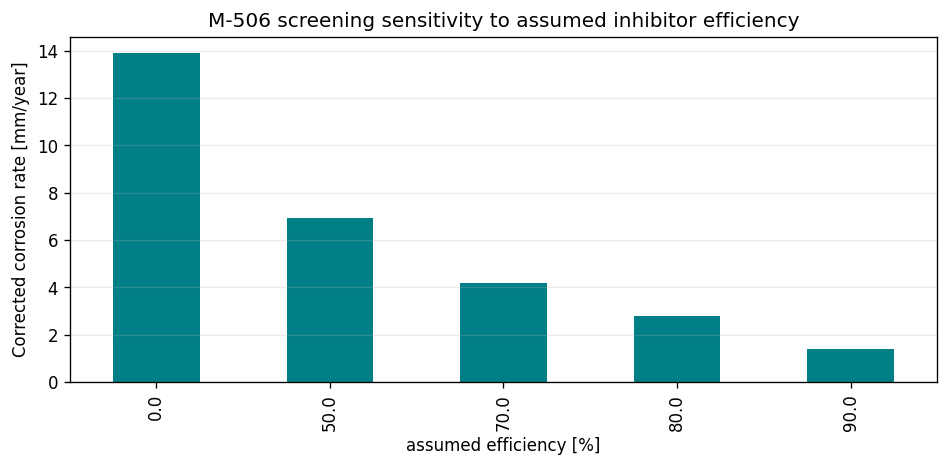

In [3]:
efficiencies = [0.0, 0.5, 0.7, 0.8, 0.9]
rows = []
for efficiency in efficiencies:
    case = run_case(efficiency).getValue()
    rows.append({
        'assumed efficiency [%]': 100.0 * efficiency,
        'rate [mm/year]': float(case.getCorrectedCorrosionRateMmPerYear()),
        '25-year projected loss [mm]': float(case.getProjectedUniformWallLossMm()),
    })
sensitivity = pd.DataFrame(rows)
display(sensitivity.round(3))

ax = sensitivity.plot.bar(x='assumed efficiency [%]', y='rate [mm/year]', legend=False,
                          color='#007F86', figsize=(8, 4))
ax.set_title('M-506 screening sensitivity to assumed inhibitor efficiency')
ax.set_ylabel('Corrected corrosion rate [mm/year]')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Fail-closed range behavior

The next case deliberately supplies an invalid CO2 mole fraction. The builder retains `1.2`; the kernel returns `BLOCKED` and does not execute a clamped legacy case.

In [4]:
blocked = run_case(0.0, co2_fraction=1.2)
blockers = [dict(item) for item in blocked.getReadiness().toMap().get('blockers')]
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
pd.DataFrame(blockers)[['code', 'message', 'requiredAction']]

,code,message,requiredAction
0,M506_CO2_FRACTION_INVALID,CO2 mole fraction must be above 0 and at most 1,Supply the gas-phase CO2 mole fraction
1,M506_CO2_PARTIAL_PRESSURE_OUT_OF_RANGE,CO2 partial pressure exceeds the implemented 1...,Use a method qualified for the higher CO2 part...


## Interpretation

Use the calculated rate and sensitivity to identify cases needing mitigation or better data. Do not convert the result directly into a selected wall thickness or corrosion allowance. Couple it with verified wetting and electrolyte chemistry, materials and sour-service assessment, localized-corrosion review, inhibitor reliability, inspection strategy, and the governing pipeline or piping design code.